In [158]:
import ee
import geopandas as gpd
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt


# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project="acm-research-f26")
print("Google Earth Engine initialized successfully.")

Google Earth Engine initialized successfully.


In [418]:
#load data
gdf = gpd.read_file(
    "./Data/im3_dataset.gpkg",
    layer="building"
)

gdf = gdf.to_crs(epsg=4326)

In [419]:
#select random data centers.
data_center = (
    gdf
    .dropna(subset=["geometry"])
    .sample(n=1)
    .iloc[0]
)

# get center point of building polygon
building_center = data_center.geometry.centroid

lon = building_center.x
lat = building_center.y

print("Name:", data_center["name"])
print("State:", data_center["state"])
print("Coordinates:", lon, lat)

Name: Microsoft EAT02
State: Washington
Coordinates: -120.20768921965575 47.416867893445776


In [420]:
center = ee.Geometry.Point([lon, lat])

#radius around data center
buffer_meters = 500

region = center.buffer(buffer_meters).bounds()

In [421]:
def get_latest_naip_image(region, start_year=2026, earliest_year=2020):
    for year in range(start_year, earliest_year - 1, -1):
        naip = (
            ee.ImageCollection("USDA/NAIP/DOQQ")
            .filterBounds(region)
            .filterDate(f"{year}-01-01", f"{year + 1}-01-01")
            .sort("system:time_start", False)

        )
        image_count = naip.size().getInfo()
        print(f"Year: {year}, Image Count: {image_count}")

        if image_count > 0:
            image = ee.Image(naip.first())
            date = (
                ee.Date(image.get("system:time_start"))
                .format("YYYY-MM-dd")
                .getInfo()
            )
            return image, date, year
    return None, None, None

Year: 2026, Image Count: 0
Year: 2025, Image Count: 0
Year: 2024, Image Count: 0
Year: 2023, Image Count: 1
Image saved to: Data/temp/Microsoft_EAT02_2023-07-11.png


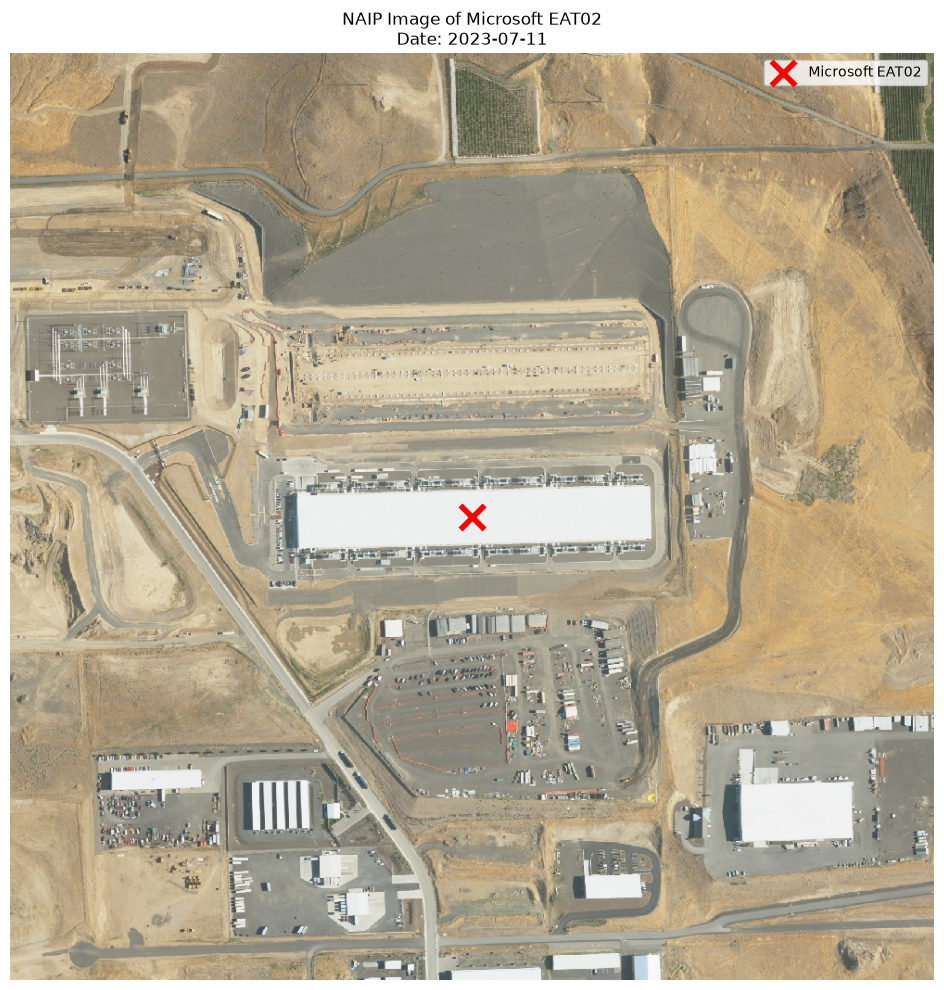

In [422]:
image, date, year = get_latest_naip_image(region)
if image is None:
    raise ValueError("No NAIP images found between 2020 and 2026.")

rgb = image.select([
    "R",
    "G",
    "B"
])

#download preview image from Earth Engine
vis_params = {
    "bands": ["R", "G", "B"],
    "min": 0,
    "max": 255,
    "dimensions": 1000,
    "region": region
}

url = rgb.getThumbURL(vis_params)

response = requests.get(url)
response.raise_for_status()

satellite_image = Image.open(
    BytesIO(response.content)
)

#save image to temp folder

temp_folder = Path("./Data/temp")
temp_folder.mkdir(parents=True, exist_ok=True)

safe_name = str(data_center["name"]).replace("/", "_").replace(" ", "_")

file_path = temp_folder / f"{safe_name}_{date}.png"

satellite_image.save(file_path)

print("Image saved to:", file_path)



#display image 
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(satellite_image)
# image dimensions
width, height = satellite_image.size

# get geographic bounds of image
bounds = region.bounds().coordinates().getInfo()[0]

# bounding box coordinates
min_lon = bounds[0][0]
min_lat = bounds[0][1]

max_lon = bounds[2][0]
max_lat = bounds[2][1]

# convert data center lon/lat to image pixel coordinates
center_x = ((lon - min_lon) / (max_lon - min_lon)) * width

center_y = ((max_lat - lat) / (max_lat - min_lat)) * height

# x on data center
ax.scatter(

    center_x,
    center_y,
    marker="x",
    s=300,
    color="red",
    linewidths=4,
    zorder=10,
    label=data_center["name"]
)


ax.set_title(
    f"NAIP Image of {data_center['name']}\n"
    f"Date: {date}"

)

ax.legend()
ax.axis("off")
plt.tight_layout()
plt.show()

In [423]:
#checkpoint download
from huggingface_hub import hf_hub_download

model_name = "ViT-B-32"

checkpoint_path = hf_hub_download(
    repo_id="chendelong/RemoteCLIP",
    filename=f"RemoteCLIP-{model_name}.pt",
    cache_dir="checkpoints"
)

print("Checkpoint:", checkpoint_path)

Checkpoint: /Users/kevinlam/ATLAS/checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


RemoteCLIP analyzing:
Name: Microsoft EAT02
State: Washington
Date: 2023-07-11
Saved image: Data/temp/Microsoft_EAT02_2023-07-11.png


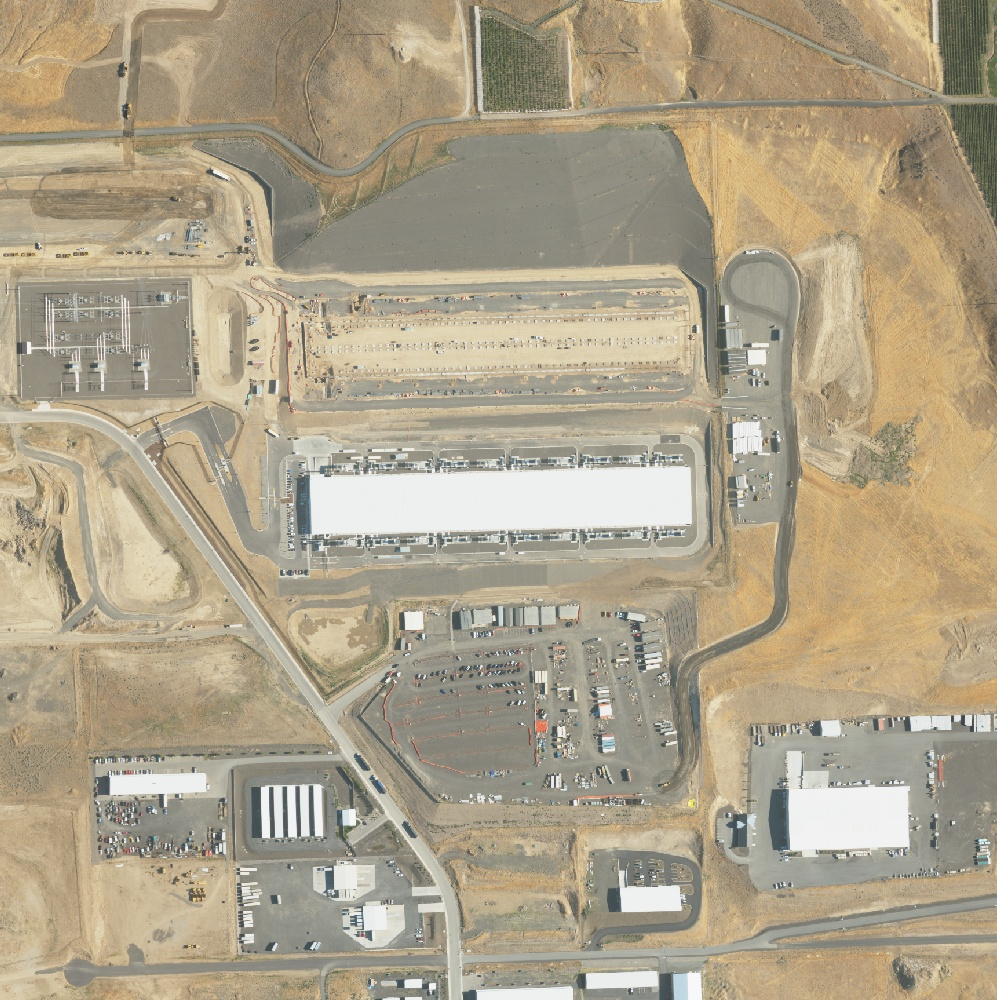

In [424]:
print("RemoteCLIP analyzing:")
print("Name:", data_center["name"])
print("State:", data_center["state"])
print("Date:", date)
print("Saved image:", file_path)

display(satellite_image)

In [411]:
#load RemoteCLIP model
import torch
import open_clip

if torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using:", device)

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name
)

tokenizer = open_clip.get_tokenizer(model_name)

ckpt = torch.load(
    checkpoint_path,
    map_location="cpu"
)

message = model.load_state_dict(ckpt)
print(message)

model = model.to(device).eval()

Using: mps


<All keys matched successfully>


In [425]:
#NAIP --> RemoteCLIP
valid_queries = [
    "an aerial image of an isolated industrial facility with clearly visible boundaries",
    "an aerial image of a large industrial campus with clearly visible buildings",
    "an aerial image of a suburban industrial facility with open surrounding space",
]

invalid_queries = [
    "an aerial image of a dense urban area with tightly packed buildings",
    "an aerial image of a downtown area with high-rise buildings and busy streets",
    "an aerial image where one building cannot be distinquished from other surrounding buildings"
]

text_queries = valid_queries + invalid_queries

image_input = preprocess(satellite_image.convert("RGB")).unsqueeze(0).to(device)
text_input = tokenizer(text_queries).to(device)

In [426]:
#get scores
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_input)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    probabilities = (100.0 * image_features @ text_features.T).softmax(dim=-1)[0]

    for label, prob in zip(text_queries, probabilities):
        print(f"{label}: "
              f"{prob.item() * 100:.2f}%")

an aerial image of an isolated industrial facility with clearly visible boundaries: 61.04%
an aerial image of a large industrial campus with clearly visible buildings: 0.39%
an aerial image of a suburban industrial facility with open surrounding space: 6.49%
an aerial image of a dense urban area with tightly packed buildings: 0.48%
an aerial image of a downtown area with high-rise buildings and busy streets: 0.01%
an aerial image where one building cannot be distinquished from other surrounding buildings: 31.59%


In [ ]:
#KEEP / REJECT decision

similarities = (image_features @ text_features.T)[0]
num_valid = len(valid_queries)

valid_scores = similarities[:num_valid]
invalid_scores = similarities[num_valid:]

best_valid = valid_scores.max().item()
best_invalid = invalid_scores.max().item()

margin = best_valid - best_invalid

print(f"Best valid score: {best_valid:.4f}")
print(f"Best invalid score: {best_invalid:.4f}")

if margin > 0:
    decision = "KEEP"
else:
    decision = "REJECT"

print(f"Decision: {decision}")

Best valid score: 0.2340
Best invalid score: 0.2275
Decision: KEEP
